<h2>P1: Max-Cut Problem</h2>
We will guide you through the design of a factor-2 approximation algorithm for the Max-Cut problem. You are given an undirected graph  𝐺 with  𝑛 vertices and  𝑚 edges.

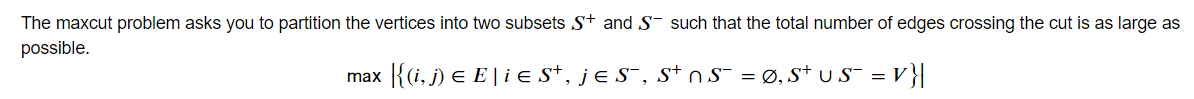

<h3>Example</h3>
Consider the graph below:

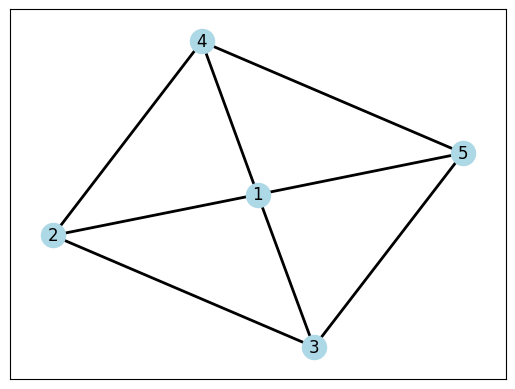

In [1]:
import networkx as nx
from matplotlib import pyplot as plt 

def draw_graph(n, edge_list, node_set_flag, set1_color='lightblue', set2_color='red'):
    # get the list of nodes in various sets and edges that are cut and uncut
    set1_nodes = [i for i in range(1, n+1) if node_set_flag[i-1] == True]
    set2_nodes = [i for i in range(1, n+1) if node_set_flag[i-1] == False]
    edge_list_not_cut = [(i,j) for (i,j) in edge_list if node_set_flag[i-1] == node_set_flag[j-1] ]
    edge_list_cut = [(i,j) for (i,j) in edge_list if node_set_flag[i-1] != node_set_flag[j-1] ]
    # now draw the graph
    G = nx.Graph()
    G.add_edges_from(edge_list)
    pos = nx.spring_layout(G, seed=1234)
    plt.figure()
    nx.draw_networkx_nodes(G, pos, nodelist=set1_nodes, node_color=set1_color)
    if len(set2_nodes) >= 1:
        nx.draw_networkx_nodes(G, pos, nodelist=set2_nodes, node_color=set2_color, alpha=0.5)
    
    labels = {i:i for i in range(1, n+1)}
    nx.draw_networkx_labels(G, pos,  labels=labels)
    
    nx.draw_networkx_edges(G, pos, width=2, edgelist = edge_list_not_cut)
    nx.draw_networkx_edges(G, pos, width=2, edgelist = edge_list_cut, edge_color='red')
    plt.show()
    

n = 5
edges = [(1,2),(1,3),(1,4),(1,5), (2,3),(2,4),(3,5),(4,5)]
node_set_flag = [True, True, True, True, True] # all nodes are in set1
draw_graph(5, edges, node_set_flag)


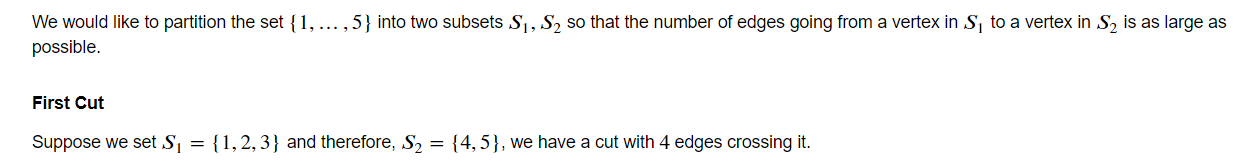

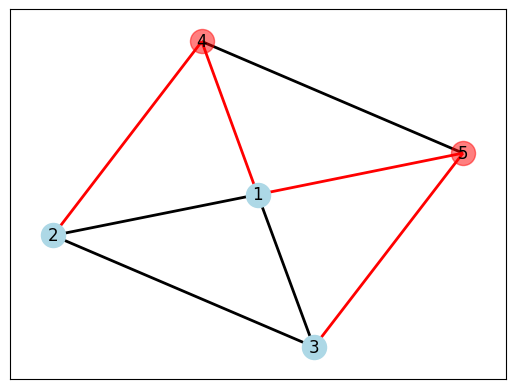

In [2]:
n = 5
edges = [(1,2),(1,3),(1,4),(1,5), (2,3),(2,4),(3,5),(4,5)]
node_set_flag = [True, True, True, False, False] # 1, 2, 3 are in set1
draw_graph(5, edges, node_set_flag)


Therefore, the MAXCUT problem asks you to find a cut with as many edges as possible crossing the cut. This problem is often encountered in applications such as circuit layout in chip design where we have a graph between the circuit components and the edges are formed by wires going between these components.

MAXCUT is known to be NP-complete though we will not ask you to prove it here. The goal of this problem is to design a greedy algorithm and prove an approximation guarantee.

<h3>Greedy Algorithm</h3>
Suppose you have a graph  𝐺 and we propose a partition of the vertices  𝑆1,𝑆2. We say that a node  𝑣
  is <u>imbalanced</u> if it has strictly more number of edges to other nodes within its partition than edges crossing the cut.

<h4> Examples</h4>
As an example, consider the graphs shown above and the first cut we showed above with  𝑆1={1,2,3} and  𝑆2={4,5}. Notice that vertices  2 and  3 are imbalanced.

However, if we consider the second cut of the graph above, we have  𝑆1={1,2,5} and  𝑆2={3,4} we see that all nodes are balanced in this cut.

<h4>P1: Design a Greedy Algorithm</h4>

Design a greedy algorithm that starts from an arbitrary (random?) initial partition, detects if there are imbalanced vertices and uses that information to find a partition with a better cut. Your algorithm should yield a partition with no imabalanced nodes in the final result.

Write down the pseudocode and prove that the algorithm terminates/find its time complexity.

Note These problems are meant for you to develop your own thinking/problem solving and will not be graded due to the online nature of this class. We will be grading just the programming assignments based on test cases. The answers to select questions are given at the end of the notebook.

<u>My thought</u> 
Two sets set1 {initially has vertex 1} set2 {initially has 2,..,n vertices} / 2 max-priority queues (each having elements of one set along with their incidence_in_set)/ cross_count=0 / owner_set_is_setone[n]   { if calling set.contains vertex is costly } /incidence[n] calculated only once and not updated after that / indicence_in_set[n] { holds the current incidence_in_set value for any given vertex}/ adjacency list representation
def algo():
  initialize set1 & set2, pq1, pq2, owner_set_isone, incidence[n]
  while(pq1.max() >cross_count || pq2.max> cross_count){
    if(pq1.max() >cross_count){
      current_vertex = pq1.pop()
      incidence_in_prev_set = current_vertex.value
      //move current vertex to other set
      move(current_vertex, owner_set_is_setone[current_vertex]? 2 : 1, incidence_in_prev_set)
    }
  }

def move(u, set, incidence_in_prev_set):
owner_set_is_setone[u] = !owner_set_is_setone[u]
owner_set_is_setone[u] ? set1.add(u);set2.remove(u); :  set2.add(u);set1.remove(u);
incidence_in_set = incidence[u] - sum[ 1 for v in adjacency[u] if owner_set_is_setone[u]==owner_set_is_setone[v]] # incidence - number of edges of vertex  in the same set vertex is in
owner_set_is_setone[vertex] ? pq1.add(u, incidence_in_set) : pq2.add(u, incidence_in_set)
cross_count = cross_count + incidence_in_prev_set - incidence_in_set
  
<h3>class algorithm</h3>

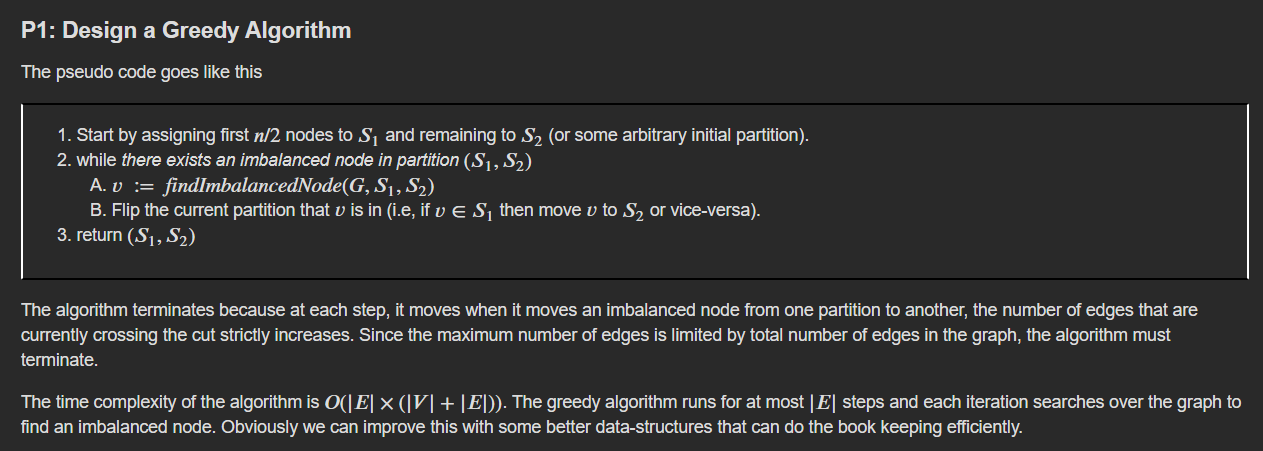


<h4>P2: Implement the Greedy Algorithm</h4>
Now let's implement the greedy algorithm to find a cut of the graph with no imbalanced vertices.
The graph will be given as an adjacency list representation.
- Vertex set will be  {0,…,𝑛−1} where  𝑛 (the number of vertices) is a input parameter
- adj_list is an adjacency list which is given as a list of sts. For instance adj_list[i] for a vertex  𝑖
  is a set to all vertices connected to vertex  𝑖.
  Note that since the graph is undirected, if  𝑗 lies in adj_list[i], we know that  𝑖 will be in adjacency_list[j]
  You can assume that the graph has no self loops or multiple edges between same pairs of nodes

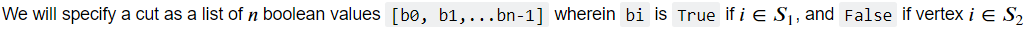

Implement the overall function find_balanced_cut that takes a graph as input and returns a list of Booleans specifying the final cut obtained by running the greedy algorithm. Please pay attention to efficiency, we will be running some large graphs through your code and it should run within a few seconds on graphs with thousands of nodes.


In [18]:
import heapq

# This is the function that you will implement the greedy algorithm
# It should input a graph as an adjacency list and return a partition where 
# every vertex is balanced, as described above.
# Return a list of Booleans of size n, wherein for any vertex v, if list[v] = True then 
# it belongs to partition S1 otherwise to partition S2.
def find_balanced_cut(n, adj_list): 
    assert n >= 1
    assert len(adj_list) == n
    incidences = [0]*n
    # Check that the adjacency list makes sense and represents a directed graph
    for (i, neighbors) in enumerate(adj_list):
        assert all( 0 <= j < n for j in neighbors )
        assert i not in neighbors # no self loops allowed
        incidences[i] = len(neighbors)
        for j in neighbors: 
            assert i in adj_list[j]
    # just start with an initial cut that places first node in S1 and rest in S2.
    cut = [True if i==0 else False for i in range(n)]
    cross_cut = incidences[0]
    ## TODO: now run the greedy algorithm. It will be helpful to have helper functions to find 
    ## imbalanced_vertices, maintain an array with the number of edges for each node that are cut and so on.
    ## Note: your algorithm must return a cut where all nodes are balanced.
    set1 = set([x for x in range(n) if x==0 ])
    set2 = set([x for x in range(n) if x!=0 ])
    
    q1 = [] 
    q2 = []
    for x in set1:
        incidence_in_set = sum([1 for y in adj_list[x] if cut[x]==cut[y] ])
        heapq.heappush(q1, (0-incidence_in_set, x))
    for x in set2:
        incidence_in_set = sum([1 for y in adj_list[x] if cut[x]==cut[y] ])
        heapq.heappush(q2, (0-incidence_in_set, x))
    while( (len(q1)>0 and q1[0][0]>cross_cut) or (len(q2)>0 and q2[0][0]>cross_cut)):
        if (len(q1)>0 and q1[0][0]>cross_cut): # move vertex to set2
            (prev_set_incidence, current_vertex) = heapq.heappop(q1)
        if (len(q2)>0 and q2[0][0]>cross_cut): # move vertex to set1
            (prev_set_incidence, current_vertex) = heapq.heappop(q2)
        moveSet(prev_set_incidence, current_vertex, cut[current_vertex], cut, set1, set2, incidences, adj_list, cross_cut)
    return cut

def moveSet(prev_set_incidence, u, to_set2, cut, set1, set2, incidences, adj_list, cross_cut):
    cut[u] = not cut[u]
    if to_set2:
        set2.append(u)
    else:
        set1.append(u)
    new_incidence_in_set = sum([1 for v in adj_list[u] if cut[u] == cut[v]])
    cross_cut = cross_cut + prev_set_incidence - new_incidence_in_set


In [4]:
#These  are useful functions for the test cases
# IMPORTANT: 
# Please ensure that you run these cells before running test cases or else you may get unknown function errors.

# Make an adjacency list out of a list of edges.
def mk_adjacency_list(n, edge_list):
    adj_list = [set() for i in range(n)]
    for (i,j) in edge_list:
        adj_list[i].add(j)
        adj_list[j].add(i)
    return adj_list

# Test Partition
def test_cut(n, adj_list, cut):
    num_edges_crossing_cut = [0]*n
    for (i, neighbors) in enumerate(adj_list):
        num_edges_crossing_cut[i] = sum([cut[i] != cut[j] for j in neighbors])
        if 2 * num_edges_crossing_cut[i] < len(neighbors):
                assert f'Test Failed: In your cut, vertex {i} has {len(neighbors)} edges incident on it but only {num_edges_crossing_cut[i]} edges cross the cut'
    return 
    

In [19]:
n = 5
edge_list =  [(0,1),(0,2),(0,3),(0,4), (1,2),(1,3),(2,4),(3,4)]
adj_list = mk_adjacency_list(n, edge_list)
print(f'Adjacency list is {adj_list}')
cut = find_balanced_cut(n, adj_list)
test_cut(n, adj_list, cut)
print('Tests Passed (5 points)')

Adjacency list is [{1, 2, 3, 4}, {0, 2, 3}, {0, 1, 4}, {0, 1, 4}, {0, 2, 3}]
Tests Passed (5 points)


In [20]:
n = 8
edge_list = [ (0,1), (0,2), (0,3), (0,4), (0,5), (0,6),
               (1, 2), (1,3), (1,4), (1,5), (1, 6), (1,7),
                 (2, 3), (2, 5), (2, 7), 
                   (3,4), (3, 6), (3, 7),
                     (4,6), (4, 6), (4, 7),
                        (5,6), (5,7),
                         (6,7)]
adj_list = mk_adjacency_list(n, edge_list)
print(f'Adjacency list is {adj_list}')
cut = find_balanced_cut(n, adj_list)
test_cut(n, adj_list, cut)

print('Tests Passed (5 points)')

Adjacency list is [{1, 2, 3, 4, 5, 6}, {0, 2, 3, 4, 5, 6, 7}, {0, 1, 3, 5, 7}, {0, 1, 2, 4, 6, 7}, {0, 1, 3, 6, 7}, {0, 1, 2, 6, 7}, {0, 1, 3, 4, 5, 7}, {1, 2, 3, 4, 5, 6}]
Tests Passed (5 points)


In [21]:
## WARNING: these graphs are going to be large. Make sure that your code is efficient enough to finish running this cell
## within 1 minute at worst.
## Our referene solution finishes in nearly 100 milli seconds on a macbook pro laptop
# running intel core i7 3.1 GHz processor
# if you are curious.
from random import randint
def mk_random_graph(n, m):
    adj_list = [set() for i in range(n)]
    for k in range(m):
        i = randint(0, n-1)
        j = randint(0, n-1)
        if i == j: 
            continue
        adj_list[i].add(j)
        adj_list[j].add(i)
    return adj_list


adj_list = mk_random_graph(100, 1000) # making random graph with 100 nodes and 10000 edges
cut = find_balanced_cut(100, adj_list)
test_cut(100, adj_list, cut)


adj_list = mk_random_graph(100, 1000) # making random graph with 100 nodes and 1000 edges
cut = find_balanced_cut(100, adj_list)
test_cut(100, adj_list, cut)


adj_list = mk_random_graph(250, 2500) # making random graph with 250 nodes and 2500 edges
cut = find_balanced_cut(250, adj_list)
test_cut(250, adj_list, cut)



adj_list = mk_random_graph(500, 10000) # making random graph with 250 nodes and 2500 edges
cut = find_balanced_cut(500, adj_list)
test_cut(500, adj_list, cut)

print('Test Passed (15 points)')


Test Passed (15 points)


<h3>Q3. Approximation Guarantee</h3>
Suppose we have a graph 𝐺  and a partition 𝑆1,𝑆2 of its vertices such that there are no imbalanced vertices. Show that at least half the edges in the graph must connect a node from 𝑆1
 to one in 𝑆2.

Therefore, show that the greedy algorithm is a factor-2 approximation algorithm: I.e, if OPT is the optimal cut and  𝐶 is that of the greedy algorithm, we have:

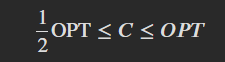

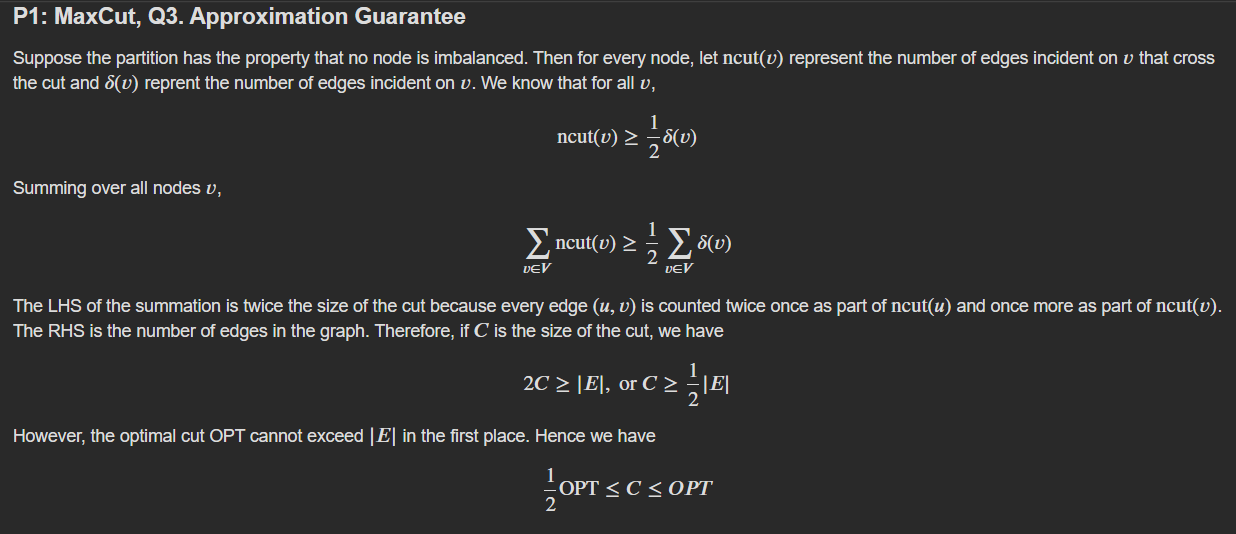

<h3>P2: k-Centers Clustering Problem</h3>

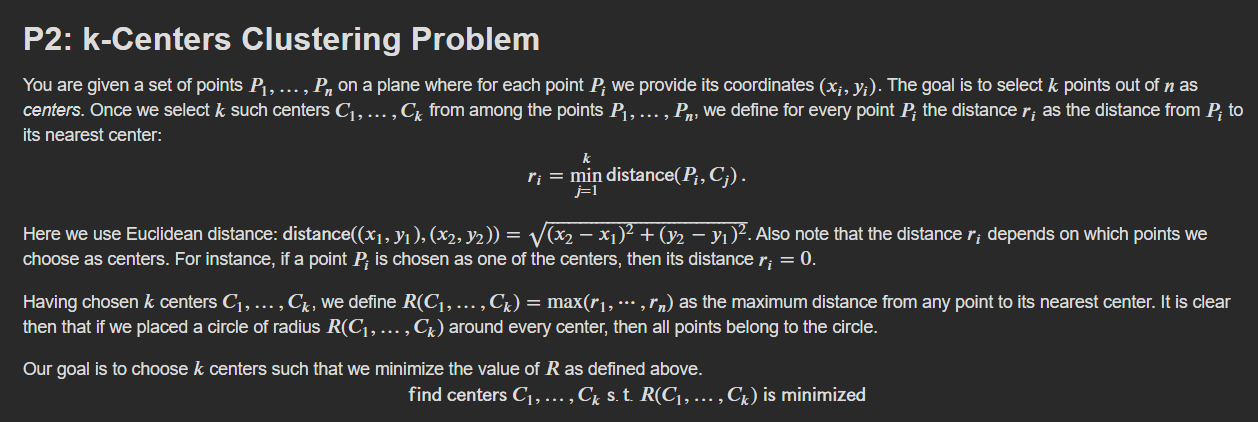

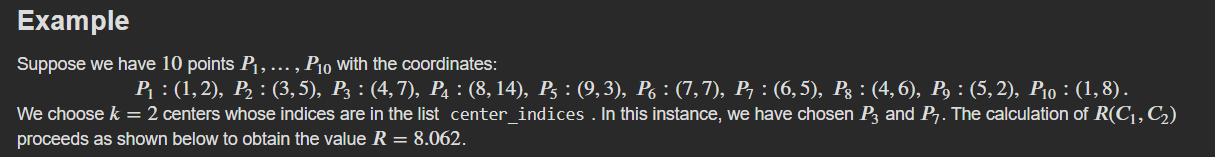

R = 8.06225774829855


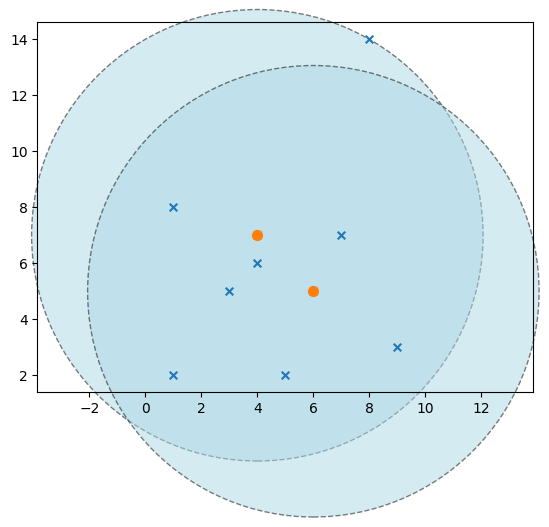

In [22]:
from math import sqrt 
from matplotlib import pyplot as plt 


def euclidean_distance(a, b):
    (xa, ya) = a
    (xb, yb) = b
    return sqrt( (xb - xa)**2 + (yb - ya)**2)

def calculate_R(coords, center_indices):
    n = len(coords)
    assert all( 0 <= j < n for j in center_indices)
    rj_values = [ min([euclidean_distance(xj, coords[j]) for j in center_indices]) for xj in coords]
    return max(rj_values)

def plot_coords(coords, center_indices):
    R = calculate_R(coords, center_indices)
    coords_x = [x for (x,y) in coords]
    coords_y = [y for (x, y) in coords]
    centers_x = [coords_x[j] for j in center_indices]
    centers_y = [coords_y[j] for j in center_indices]
    figure, axes = plt.subplots()
    axes.axis('equal')
    for k in center_indices:
        c = plt.Circle(coords[k], R, fill=True, alpha=0.5, facecolor='lightblue', clip_on=False, edgecolor='black', linewidth=1, linestyle='dashed')
        axes.add_artist(c)
    plt.scatter(coords_x, coords_y, s=30, marker='x' )
    plt.scatter(centers_x, centers_y, s=50, marker='o')
    plt.show()
    
coords = [(1,2), (3,5), (4,7), (8, 14), (9,3), (7,7), (6,5), (4, 6), (5,2), (1,8)]
center_indices = [2, 6] # remember indexing starts from 0 in python arrays
R = calculate_R(coords, center_indices)
print(f'R = {R}')
plot_coords(coords, center_indices)
    

However, if we instead chose centers:  𝑃2 and  𝑃6, we obtain a smaller  𝑅=7.071.

R = 7.0710678118654755


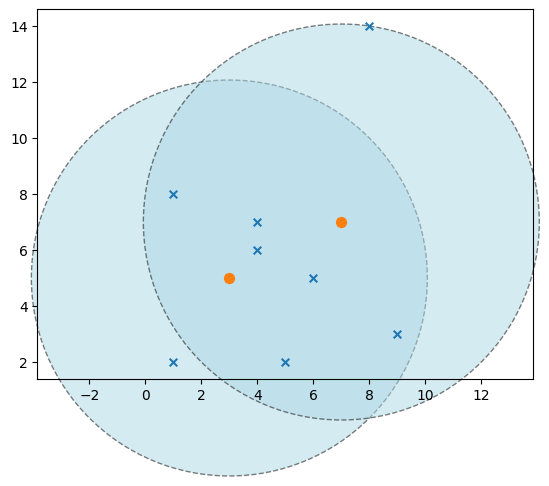

In [23]:
coords = [(1,2), (3,5), (4,7), (8, 14), (9,3), (7,7), (6,5), (4, 6), (5,2), (1,8)]
center_indices = [1, 5] # remember indexing starts from 0 in python arrays
R = calculate_R(coords, center_indices)
print(f'R = {R}')
plot_coords(coords, center_indices)

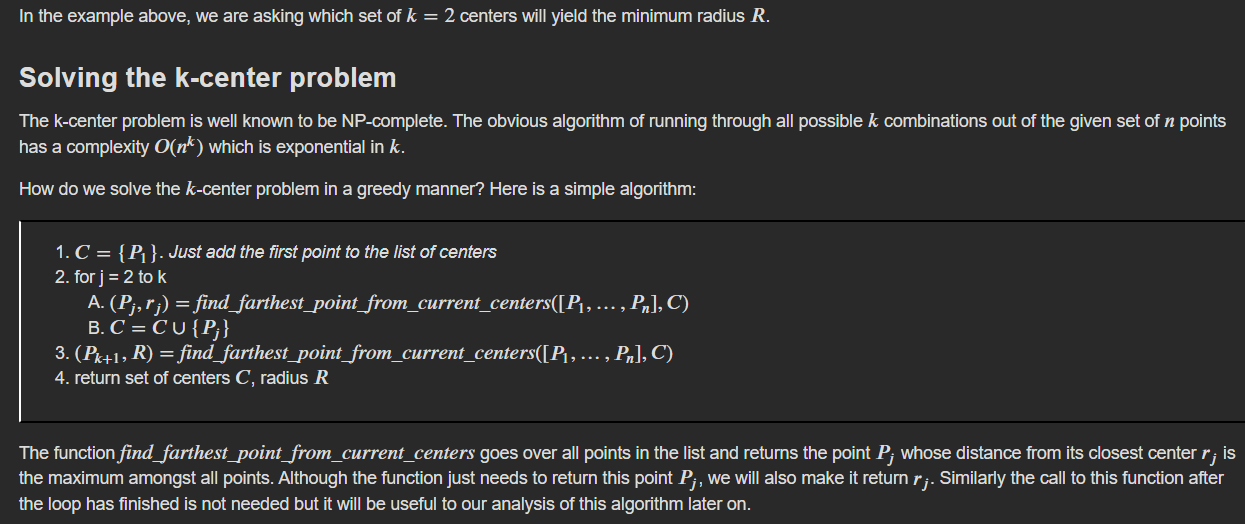

In [25]:
def euclidean_distance(a, b):
    (xa, ya) = a
    (xb, yb) = b
    return sqrt( (xb - xa)**2 + (yb - ya)**2)


# Function find_farthest_point_from_current_centers
# returns a pair (j, rj) where 
# - 0 <= j < len(coords) is the index of the farthest point P_j
# - rj is the distance of the point P_j from its nearest center
def find_farthest_point_from_current_centers(coords, center_indices):
    n = len(coords)
    assert all( 0 <= j < n for j in center_indices)
    rj_values = [ (min([euclidean_distance(xi, coords[j]) for j in center_indices]), i) for (i, xi) in enumerate(coords)]
    # calculate nmaximum of (distance of any point to nearest center)
    (rj, j) = max(rj_values)
    return (j, rj)

## Implement a function greedy_k_centers that given a list of coordinates `coords`, returns center_list, R
##   - centers_list is a list of indices [j1,..., jk]. Note that coords[j1], ..., coords[jk] will yield coordinates of the actual center.
##   - R is the radius resulting from the choice of the k centers
## Please use the implementation of find_farthest_point_from_current_centers above.
def greedy_k_centers(coords, k, debug=True): ## Please print messages from this function only if debug flag is True
    centers = [0] # Add the very first point 
    if debug:
        print(f'Initial center: {coords[0]}')
    # your code here
    for x in range(2,k+1):
        (p,r) =  find_farthest_point_from_current_centers(coords, centers)
        centers.append(p)
    (P,R) = find_farthest_point_from_current_centers(coords, centers)
    return (centers, R)

Initial center: (1, 2)


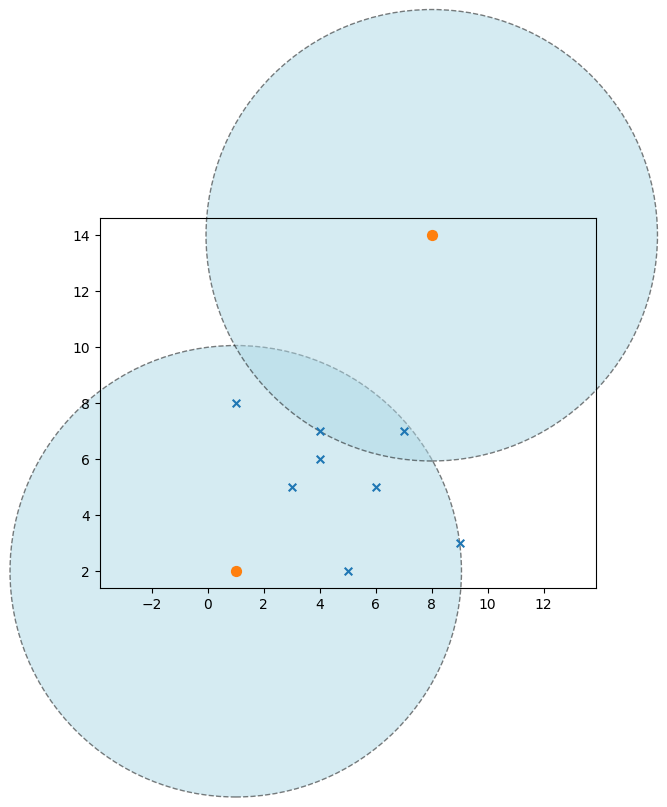

Passed test (5 points)


In [26]:
coords = [(1,2), (3,5), (4,7), (8, 14), (9,3), (7,7), (6,5), (4, 6), (5,2), (1,8)]
(center_indices, R) = greedy_k_centers(coords, 2)
plot_coords(coords, center_indices)
def calculate_R(coords, center_indices):
    n = len(coords)
    assert all( 0 <= j < n for j in center_indices)
    rj_values = [ min([euclidean_distance(xj, coords[j]) for j in center_indices]) for xj in coords]
    return max(rj_values)

assert len(center_indices) == 2
assert abs(R - calculate_R(coords, center_indices)) <= 1E-06, f'The returned value of R={R} from your function does not match with my computation. Something is wrong in your calculations'
assert 4 <= R <= 16.2
print('Passed test (5 points)')

Initial center: (1, 2)


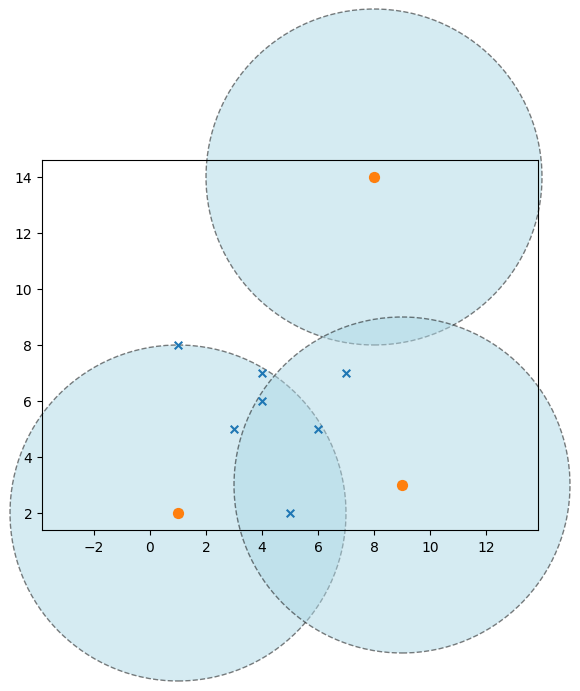

Passed test (5 points)


In [27]:
coords = [(1,2), (3,5), (4,7), (8, 14), (9,3), (7,7), (6,5), (4, 6), (5,2), (1,8)]
(center_indices, R) = greedy_k_centers(coords, 3)
plot_coords(coords, center_indices)
def calculate_R(coords, center_indices):
    n = len(coords)
    assert all( 0 <= j < n for j in center_indices)
    rj_values = [ min([euclidean_distance(xj, coords[j]) for j in center_indices]) for xj in coords]
    return max(rj_values)

assert len(center_indices) == 3
assert abs(R - calculate_R(coords, center_indices)) <= 1E-06, f'The returned value of R={R} from your function does not match with my computation. Something is wrong in your calculations'
assert 3 <= R <= 12.0
print('Passed test (5 points)')

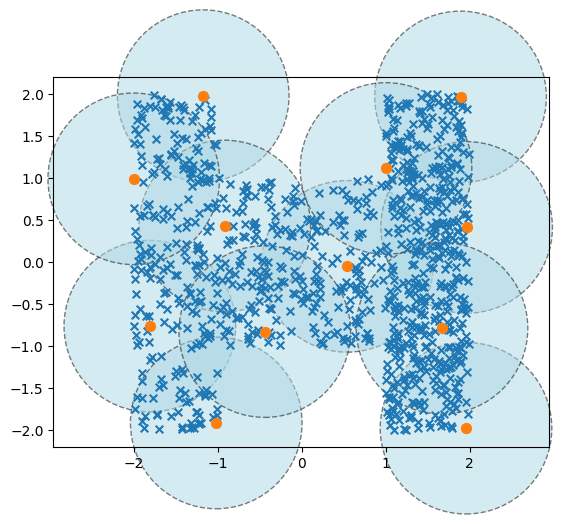

Test Passed (5 points)


In [28]:
from random import uniform
## Generate 1000 points
n = 1000
k = 12
coords = [(uniform(-2,-1), uniform(-2,2)) for i in range(n//4)] + [(uniform(-1,1), uniform(-1,1)) for i in range(n//4)] +  [(uniform(1,2), uniform(-2,0)) for i in range(n//4)] +  [(uniform(1,2), uniform(0,2)) for i in range(n//4)] 
            
(center_indices, R) = greedy_k_centers(coords, k, debug=False)
plot_coords(coords, center_indices)
def calculate_R(coords, center_indices):
    n = len(coords)
    assert all( 0 <= j < n for j in center_indices)
    rj_values = [ min([euclidean_distance(xj, coords[j]) for j in center_indices]) for xj in coords]
    return max(rj_values)

assert len(center_indices) == k
assert abs(R - calculate_R(coords, center_indices)) <= 1E-06, f'The returned value of R={R} from your function does not match with my computation. Something is wrong in your calculations'
print('Test Passed (5 points)')

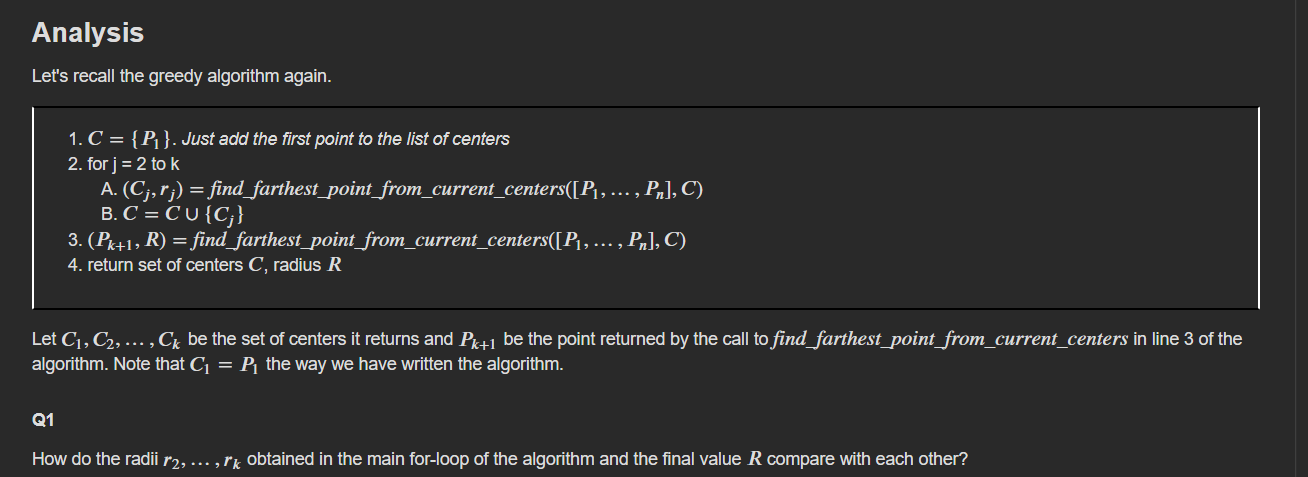

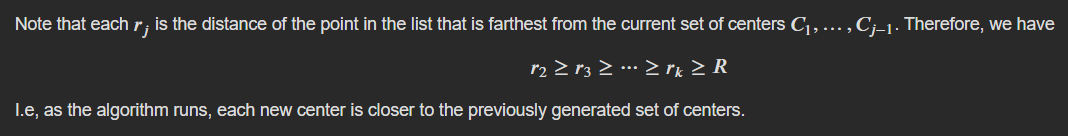

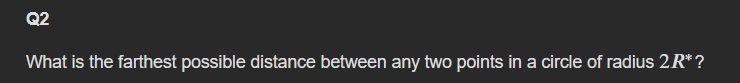

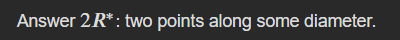

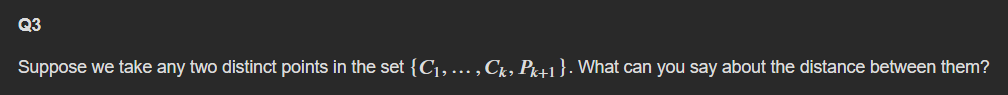

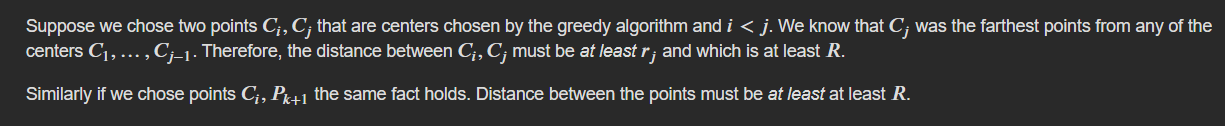

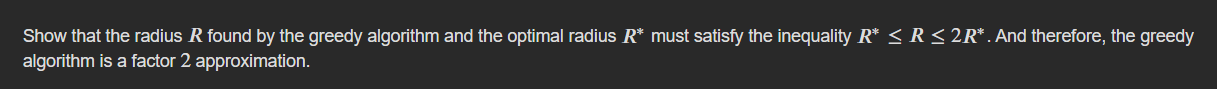

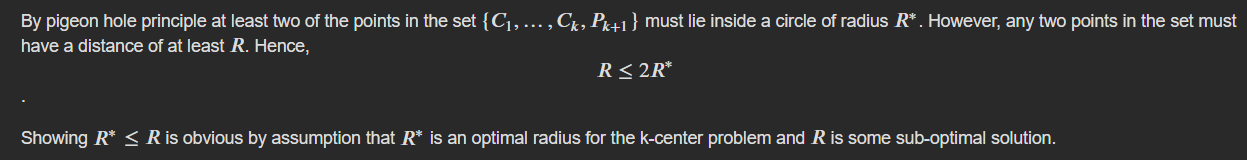
